In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('Baza_customer_Telecom_v2.csv')
df.columns = df.columns.str.strip()   # one column header had a trailing space
print(df.shape)
df.head()


(8453, 14)


,PID,CRM_PID_Value_Segment,EffectiveSegment,Billing_ZIP,KA_name,Active_subscribers,Not_Active_subscribers,Suspended_subscribers,Total_SUBs,AvgMobileRevenue,AvgFIXRevenue,TotalRevenue,ARPU,CHURN
0,123759242,Bronze,SOHO,6000.0,VM,2,NaN,NaN,2,40.17,0.0,40.17,NaN,No
1,126145737,Bronze,SOHO,6400.0,VM,3,NaN,NaN,3,40.17,0.0,40.17,13.39,No
2,123506355,Bronze,SOHO,6000.0,DI,2,3.0,NaN,5,40.17,0.0,40.17,20.09,No
3,112595585,Bronze,SOHO,4400.0,MT,1,2.0,NaN,3,40.17,0.0,40.17,40.17,No
4,115097935,Iron,SOHO,4000.0,AD,2,1.0,NaN,3,40.17,0.0,40.17,20.09,No


## 1. Data Cleaning

**Duplicate check.** `PID` is the customer ID, so duplicates should be checked on `PID`,
not on the whole row — two different customers could coincidentally share the same feature
values, but they can never share the same ID.


In [3]:
print("Duplicate PIDs:", df['PID'].duplicated().sum())
df[df['PID'].duplicated(keep=False)].sort_values('PID').head(6)


Duplicate PIDs: 17


,PID,CRM_PID_Value_Segment,EffectiveSegment,Billing_ZIP,KA_name,Active_subscribers,Not_Active_subscribers,Suspended_subscribers,Total_SUBs,AvgMobileRevenue,AvgFIXRevenue,TotalRevenue,ARPU,CHURN
7700,1.21E+12,SE,SE,4700.0,Tatiana Trifonova,3,NaN,NaN,3,58.17,0.0,58.17,19.39,No
7256,1.21E+12,Gold,SOHO,6300.0,RJ,6,NaN,NaN,6,182.17,0.0,182.17,30.36,No
7699,1.21E+12,SE,SE,4400.0,Tatiana Trifonova,17,NaN,NaN,17,262.83,0.0,262.83,15.46,No
7698,1.21E+12,Silver,SOHO,4000.0,Tatiana Trifonova,25,NaN,NaN,25,212.83,0.0,212.83,8.51,Yes
6362,1.22E+12,Bronze,SOHO,4700.0,Jenia Gogova,6,NaN,NaN,6,116.83,0.0,116.83,19.47,Yes
7257,1.22E+12,Gold,VSE,6300.0,RJ,10,3.0,NaN,13,249.67,0.0,249.67,24.97,No


There are 17 duplicate `PID`s, and their other column values differ — so these look like
the same customer appearing more than once (e.g. a different billing period), not a data-entry
error. We'll leave them in the data rather than deleting real records.


In [4]:
df.isnull().sum()


PID                          0
CRM_PID_Value_Segment        5
EffectiveSegment             0
Billing_ZIP                  2
KA_name                      0
Active_subscribers           0
Not_Active_subscribers    4149
Suspended_subscribers     8101
Total_SUBs                   0
AvgMobileRevenue             0
AvgFIXRevenue                0
TotalRevenue                 0
ARPU                         1
CHURN                        0
dtype: int64

`Not_Active_subscribers` and `Suspended_subscribers` have a lot of missing (blank) cells.
A blank numeric cell and `NaN` are the same thing — but here it almost certainly means **zero**
subscribers of that type, not "unknown", because `Active + Not_Active + Suspended` should equal
`Total_SUBs`. Let's check:


In [5]:
filled = df[['Active_subscribers', 'Not_Active_subscribers', 'Suspended_subscribers', 'Total_SUBs']].fillna(0)
mismatch = (filled['Active_subscribers'] + filled['Not_Active_subscribers'] + filled['Suspended_subscribers']) != filled['Total_SUBs']
print("Rows that don't add up after filling with 0:", mismatch.sum(), "out of", len(df))


Rows that don't add up after filling with 0: 0 out of 8453


It matches for every row, so filling with 0 is the correct choice — not dropping the columns.
The remaining missing values (`CRM_PID_Value_Segment`, `Billing_ZIP`, `ARPU`) are only a handful
of rows each, so we simply drop those rows.


In [ ]:
df['Not_Active_subscribers'] = df['Not_Active_subscribers'].fillna(0)
df['Suspended_subscribers'] = df['Suspended_subscribers'].fillna(0)
df = df.dropna(subset=['CRM_PID_Value_Segment', 'Billing_ZIP', 'ARPU'])

df['CRM_PID_Value_Segment'] = df['CRM_PID_Value_Segment'].replace({'Sliver': 'Silver'})

print(df.isnull().sum().sum(), "missing values left")


0 missing values left


In [ ]:
df['churn'] = (df['CHURN'] == 'Yes').astype(int)
df['churn'].value_counts(normalize=True)


churn
0    0.934991
1    0.065009
Name: proportion, dtype: float64

## 2. Feature Engineering

Feature engineering means creating new columns from the ones you already have, so the model
gets a more useful signal than the raw fields alone. Two simple, clearly-motivated features here:

- `active_ratio` = `Active_subscribers / Total_SUBs` — how much of a customer's subscriptions are actually active (a low ratio could mean the customer is close to churning)
- `revenue_per_sub` = `TotalRevenue / Total_SUBs` — revenue per subscription, not just the raw total


In [8]:
df['active_ratio'] = df['Active_subscribers'] / df['Total_SUBs']
df['revenue_per_sub'] = df['TotalRevenue'] / df['Total_SUBs']
df[['active_ratio', 'revenue_per_sub']].describe()


,active_ratio,revenue_per_sub
count,8445.000000,8445.000000
mean,0.839106,19.350465
std,0.212319,15.896444
min,0.006250,0.155667
25%,0.750000,11.405000
50%,0.933333,15.861667
75%,1.000000,22.637059
max,1.000000,426.000000


## 3. Data Visualization

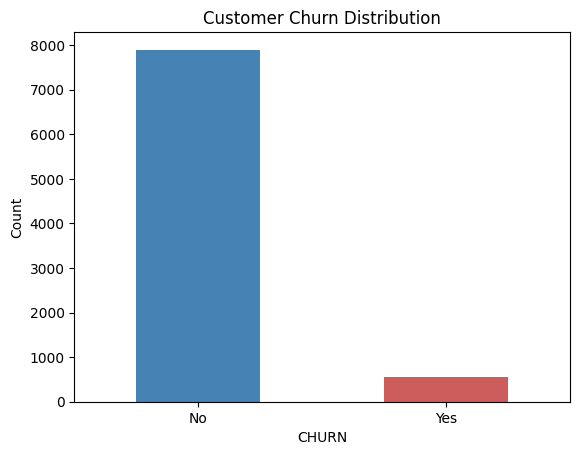

CHURN
No     0.935
Yes    0.065
Name: proportion, dtype: float64


In [ ]:
df['CHURN'].value_counts().plot(kind='bar', color=['steelblue', 'indianred'])
plt.title('Customer Churn Distribution')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.show()

print(df['CHURN'].value_counts(normalize=True).round(3))

Only about **6.5% of customers churned** — a heavily imbalanced dataset, which is the main challenge


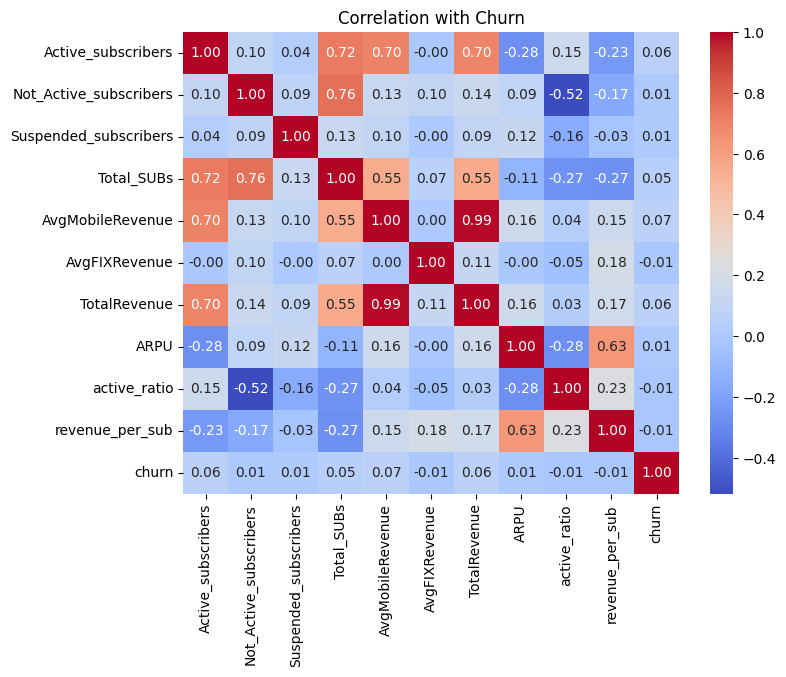

In [10]:
num_col = ['Active_subscribers', 'Not_Active_subscribers', 'Suspended_subscribers',
           'Total_SUBs', 'AvgMobileRevenue', 'AvgFIXRevenue', 'TotalRevenue', 'ARPU',
           'active_ratio', 'revenue_per_sub']

# Billing_ZIP is stored as a number but it's really a postal code (a category), not a quantity,
# so we keep it out of the numeric list and treat it as categorical instead.
cat_col = ['CRM_PID_Value_Segment', 'EffectiveSegment', 'KA_name']

corr = df[num_col + ['churn']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation with Churn')
plt.show()


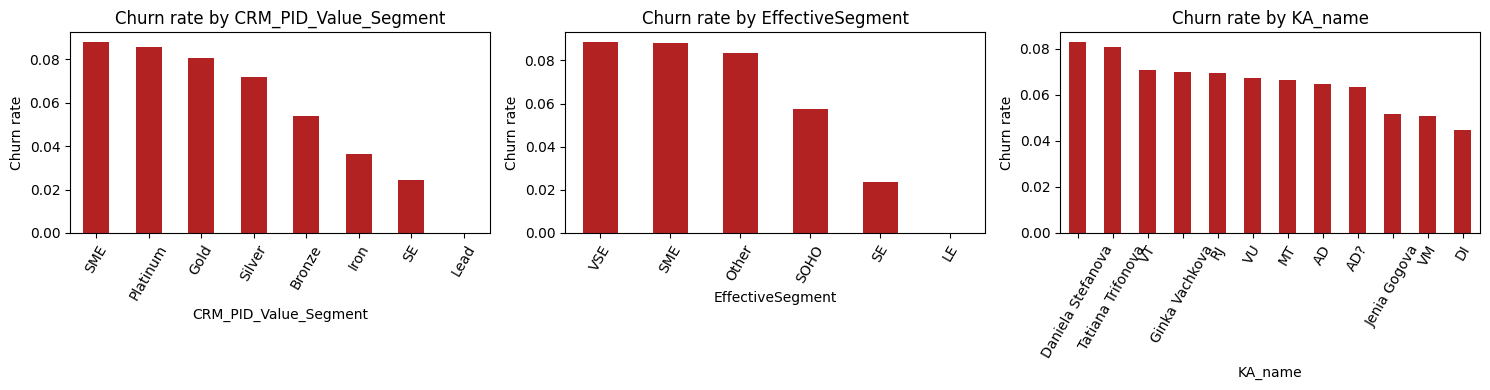

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, cat_col):
    df.groupby(col)['churn'].mean().sort_values(ascending=False).plot(kind='bar', ax=ax, color='firebrick')
    ax.set_title(f'Churn rate by {col}')
    ax.set_ylabel('Churn rate')
    ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()


## 4. Machine Learning Models (Question 1)

We have to train three models, Logistic Regression, SVC, and Random Forest — and we will use **SMOTE** inside each pipeline to handle the class imbalanc e


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


In [ ]:
x = df[num_col + cat_col]
y = df['churn']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=23, stratify=y)
print("Train shape:", x_train.shape, " Test shape:", x_test.shape)


Train shape: (6756, 13)  Test shape: (1689, 13)


In [14]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_col),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_col),
])


In [15]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=23)),
    ('model', LogisticRegression(max_iter=1000))
])
lr_pipeline.fit(x_train, y_train)
lr_prediction = lr_pipeline.predict(x_test)
print(classification_report(y_test, lr_prediction))


              precision    recall  f1-score   support

           0       0.95      0.59      0.73      1579
           1       0.08      0.55      0.15       110

    accuracy                           0.59      1689
   macro avg       0.52      0.57      0.44      1689
weighted avg       0.89      0.59      0.69      1689



In [16]:
svc_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=23)),
    ('model', SVC(kernel='linear', C=1.0))
])
svc_pipeline.fit(x_train, y_train)
svc_prediction = svc_pipeline.predict(x_test)
print(classification_report(y_test, svc_prediction))


              precision    recall  f1-score   support

           0       0.95      0.54      0.69      1579
           1       0.08      0.55      0.13       110

    accuracy                           0.54      1689
   macro avg       0.51      0.55      0.41      1689
weighted avg       0.89      0.54      0.65      1689



In [17]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=23)),
    ('model', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=23))
])
rf_pipeline.fit(x_train, y_train)
rf_prediction = rf_pipeline.predict(x_test)
print(classification_report(y_test, rf_prediction))


              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1579
           1       0.12      0.12      0.12       110

    accuracy                           0.89      1689
   macro avg       0.53      0.53      0.53      1689
weighted avg       0.89      0.89      0.89      1689



## Performance Comparison

In [18]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVC', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, lr_prediction), accuracy_score(y_test, svc_prediction), accuracy_score(y_test, rf_prediction)],
    'Precision (churn)': [precision_score(y_test, lr_prediction), precision_score(y_test, svc_prediction), precision_score(y_test, rf_prediction)],
    'Recall (churn)': [recall_score(y_test, lr_prediction), recall_score(y_test, svc_prediction), recall_score(y_test, rf_prediction)],
    'F1 (churn)': [f1_score(y_test, lr_prediction), f1_score(y_test, svc_prediction), f1_score(y_test, rf_prediction)],
}).round(3)
results


,Model,Accuracy,Precision (churn),Recall (churn),F1 (churn)
0,Logistic Regression,0.588,0.085,0.545,0.147
1,SVC,0.545,0.077,0.545,0.135
2,Random Forest,0.887,0.121,0.118,0.120


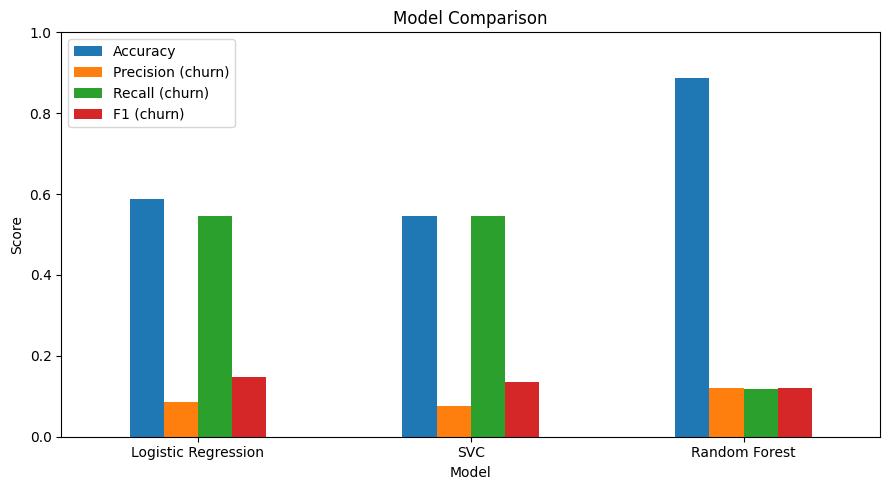

In [19]:
results.set_index('Model')[['Accuracy', 'Precision (churn)', 'Recall (churn)', 'F1 (churn)']].plot(kind='bar', figsize=(9, 5))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


### Question 1 — Which model wins, and why?

Actual results:

| Model | Accuracy | Precision (churn) | Recall (churn) | F1 (churn) |
|---|---|---|---|---|
| Logistic Regression | 0.588 | 0.085 | 0.545 | **0.147** |
| SVC (linear) | 0.545 | 0.077 | 0.545 | 0.135 |
| Random Forest | 0.887 | 0.121 | 0.118 | 0.120 |

**Logistic Regression has the best F1 for the churn class.** Random Forest has by far the best
accuracy (0.887), but that's misleading — with only ~6.5% churners, a model can get high accuracy
just by predicting "no churn" most of the time, which is exactly what Random Forest is doing here
(its recall is only 0.118, meaning it misses most actual churners).

The feature-target correlations we saw earlier were all weak (well under 0.2), so the real signal
in this data is limited and mostly simple/linear. Random Forest is a more flexible, high-variance
model — with weak features it tends to fit noise in the majority class rather than real churn
patterns. Logistic Regression's simpler, linear decision boundary handles this better, which is
why it wins on F1 even though it doesn't have the highest accuracy. In short: **with weak
features, the simpler model tends to win**, because it has less room to overfit.

### Question 2 — Preprocessing strategy for 70% missing values

- First check *why* the data is missing — is it random, or does it depend on another column
  (like we found here, where blanks meant "zero", not "unknown")? That changes the fix completely.
- Don't automatically drop a column just because it's mostly missing — check if the missingness
  itself is meaningful first, the way we tested `Total_SUBs = Active + Not_Active + Suspended` above.
- If it truly is unknown/random and 70% missing, imputing is risky (you'd be making up most of
  the column), so dropping the column is usually more honest — but add a note explaining why, since
  it's a judgment call, not a fixed rule.
- If you keep a heavily-missing column, add a simple missing-flag column alongside the imputed
  value, so the model can tell "this was originally missing" apart from a real value.
- Always fit any imputer only on the training data, not the full dataset, to avoid leakage into
  the test set.
